# CartPole UCBVI

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import sys
from typing import List, Tuple, Any
import time

# Add the workspace root to Python's path
script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_dir, "..", "..", ".."))
algorithms_dir = os.path.join(project_root, "causalgym", "causal_gym", "algorithms")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if algorithms_dir not in sys.path:
    sys.path.insert(0, algorithms_dir)

from causal_gym.envs.cartpole_wind import CartPoleWindPCH
from ucbvi import UCBVI

In [2]:
class Discretiser:
    """
    Discretises continuous observation space for CartPoleWindPCH into integer states.
    Uses symmetric ranges:
      position ∈ [-2.4, 2.4], velocity ∈ [-3.0, 3.0],
      angle ∈ [-0.20, 0.20], angular-vel ∈ [-3.5, 3.5].
    """
    def __init__(self, bins_per_dim: int):
        if not isinstance(bins_per_dim, int) or bins_per_dim <= 0:
            raise ValueError("bins_per_dim must be a positive integer.")
        self.bins_per_dim_each = np.array([bins_per_dim] * 4, dtype=np.int_)

        self.obs_low = np.array([-2.4, -3.0, -0.20, -3.5], dtype=np.float32)
        self.obs_high = np.array([2.4, 3.0, 0.20, 3.5], dtype=np.float32)
        self.num_dims = 4

        self.bin_edges: List[np.ndarray] = []
        for i in range(self.num_dims):
            edges = np.linspace(self.obs_low[i], self.obs_high[i], self.bins_per_dim_each[i] + 1)
            self.bin_edges.append(edges)

        self._n_states = int(np.prod(self.bins_per_dim_each))
        if self._n_states <= 0:
            raise ValueError("Number of states must be positive.")

    def __call__(self, obs: np.ndarray) -> int:
        bin_indices = np.empty(self.num_dims, dtype=np.int_)
        for i in range(self.num_dims):
            clipped_obs_i = np.clip(obs[i], self.obs_low[i], self.obs_high[i])
            
            if self.bins_per_dim_each[i] == 1:
                bin_indices[i] = 0
            else:
                thresholds = self.bin_edges[i][1:-1] 
                bin_indices[i] = np.digitize(clipped_obs_i, thresholds)
        
        state_index = 0
        for i in range(self.num_dims):
            state_index = state_index * self.bins_per_dim_each[i] + bin_indices[i]
        return int(state_index)

    @property
    def n_states(self) -> int:
        return self._n_states

# Test the Discretiser
_test_bins = 8
_d_test = Discretiser(bins_per_dim=_test_bins)
print(f"Testing Discretiser with {_test_bins} bins per dimension:")
print(f"Total number of states: {_d_test.n_states} (expected: {_test_bins**4})")
_test_obs = np.array([0.0, 0.0, 0.0, 0.0])
_test_idx = _d_test(_test_obs)
print(f"Test observation {_test_obs} -> state index: {_test_idx}")
assert 0 <= _test_idx < _d_test.n_states, f"Test failed: idx={_test_idx} out of range"
print("Discretiser test passed!")

Testing Discretiser with 8 bins per dimension:
Total number of states: 4096 (expected: 4096)
Test observation [0. 0. 0. 0.] -> state index: 2340
Discretiser test passed!


In [3]:
# Training parameters
config = {
    "episodes": 1000,
    "horizon": 200,
    "bins": 8,
    "delta": 0.1,
    "epsilon": 0.1,
    "seed": 42
}

print("Training Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize environment and agent
np.random.seed(config["seed"])
env = CartPoleWindPCH()
discretiser = Discretiser(bins_per_dim=config["bins"])

n_actions = env.action_space.n
agent = UCBVI(
    num_states=discretiser.n_states,
    n_actions=n_actions,
    horizon=config["horizon"],
    delta=config["delta"],
    epsilon=config["epsilon"],
    seed=config["seed"]
)

print(f"\nEnvironment initialized with {n_actions} actions")
print(f"State space discretized into {discretiser.n_states} states")

Training Configuration:
episodes: 1000
horizon: 200
bins: 8
delta: 0.1
epsilon: 0.1
seed: 42

Environment initialized with 2 actions
State space discretized into 4096 states


In [4]:
episode_returns = []
episode_regrets = []

print(f"Starting training for {config['episodes']} episodes...")
start_time = time.time()

for ep in range(config['episodes']):
    obs_continuous, _ = env.reset(seed=config['seed'] + ep)
    s = discretiser(obs_continuous)
    ep_return = 0.0
    ep_regret_steps = 0.0
    
    agent.plan()
    
    for t in range(config['horizon']):
        x_intended = np.argmax(agent.V[s, :])
        a_to_apply = agent.act(s, x_intended)
        
        obs2_continuous, r, terminated, truncated, info = env.do(a_to_apply)
        s2 = discretiser(obs2_continuous)
        done = terminated or truncated
        
        realised_action = info.get("realised_action", a_to_apply)
        agent.update(s, x_intended, realised_action, r, s2)
        
        ep_return += r
        ep_regret_steps += (1.0 - r)
        s = s2
        
        if done:
            break
    
    episode_returns.append(ep_return)
    episode_regrets.append(ep_regret_steps)
    
    if (ep + 1) % max(1, config['episodes'] // 10) == 0:
        print(f"Episode {ep+1:4d}/{config['episodes']} | Return: {ep_return:7.2f} | Steps: {t+1} | Regret: {ep_regret_steps:.2f}")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

Starting training for 1000 episodes...
  UCBVI.update: s=2276, x_int=0, a_exec=0, r=1.00, s'=2276
    N[2276,0,0]=1.0->2.0, R[2276,0,0]=0.00->0.50
  UCBVI.update: s=2276, x_int=0, a_exec=1, r=1.00, s'=2340
    N[2276,0,1]=1.0->2.0, R[2276,0,1]=0.00->0.50
  UCBVI.update: s=2340, x_int=0, a_exec=0, r=1.00, s'=2276
    N[2340,0,0]=1.0->2.0, R[2340,0,0]=0.00->0.50
  UCBVI.update: s=2276, x_int=0, a_exec=0, r=1.00, s'=2276
    N[2276,0,0]=2.0->3.0, R[2276,0,0]=0.50->0.67
  UCBVI.update: s=2276, x_int=0, a_exec=0, r=1.00, s'=2277
    N[2276,0,0]=3.0->4.0, R[2276,0,0]=0.67->0.75
  UCBVI.update: s=2277, x_int=0, a_exec=1, r=1.00, s'=1764
    N[2277,0,1]=1.0->2.0, R[2277,0,1]=0.00->0.50
  UCBVI.update: s=1764, x_int=0, a_exec=1, r=1.00, s'=1772
    N[1764,0,1]=1.0->2.0, R[1764,0,1]=0.00->0.50
  UCBVI.update: s=1772, x_int=0, a_exec=0, r=1.00, s'=1772
    N[1772,0,0]=1.0->2.0, R[1772,0,0]=0.00->0.50
  UCBVI.update: s=1772, x_int=0, a_exec=0, r=1.00, s'=1773
    N[1772,0,0]=2.0->3.0, R[1772,0,0]=

Plot saved as plots/cartpole_training_progress.png


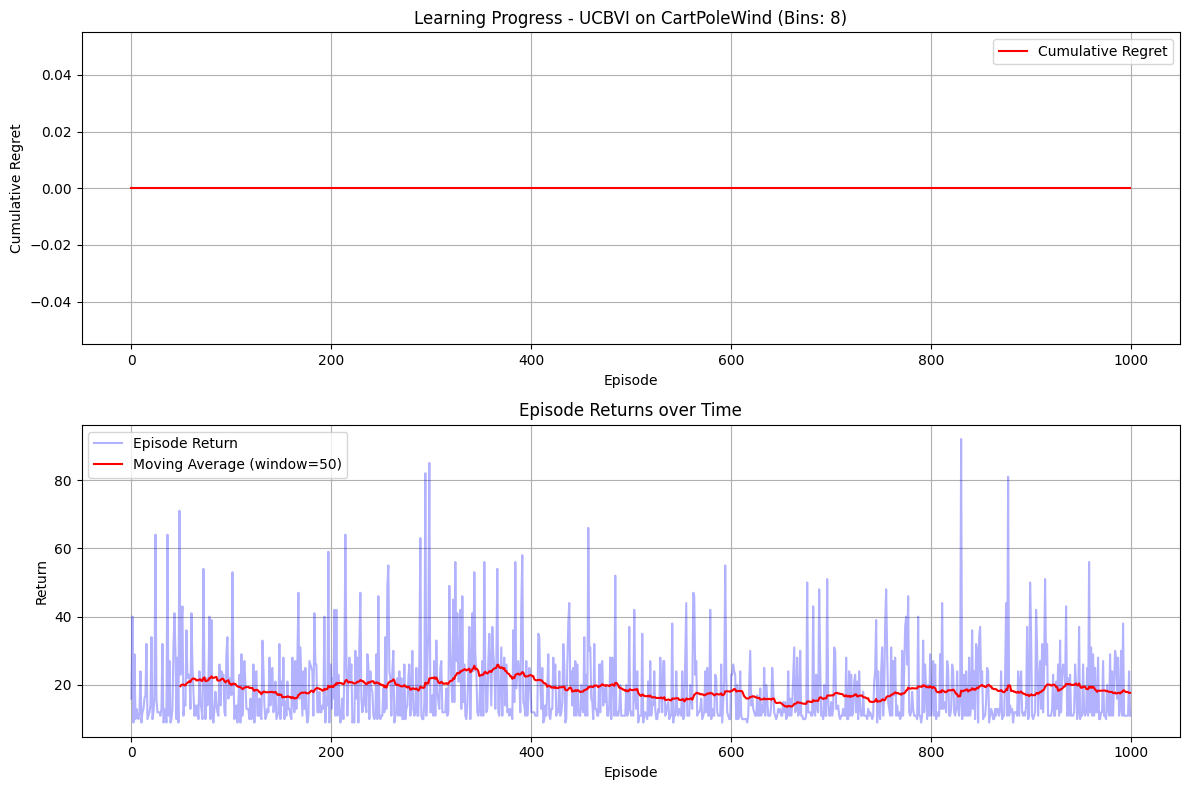

In [5]:
plt.figure(figsize=(12, 8))

# Plot cumulative regret
plt.subplot(2, 1, 1)
cumulative_regret = np.cumsum(episode_regrets)
plt.plot(cumulative_regret, 'r-', label='Cumulative Regret')
plt.xlabel('Episode')
plt.ylabel('Cumulative Regret')
plt.title(f'Learning Progress - UCBVI on CartPoleWind (Bins: {config["bins"]})')
plt.grid(True)
plt.legend()

# Plot episode returns with moving average
plt.subplot(2, 1, 2)
plt.plot(episode_returns, 'b-', alpha=0.3, label='Episode Return')
window_size = min(50, len(episode_returns) // 3)
if window_size >= 2:
    moving_avg = np.convolve(episode_returns, np.ones(window_size)/window_size, mode='valid')
    moving_avg_x = np.arange(window_size-1, len(episode_returns))
    plt.plot(moving_avg_x, moving_avg, 'r-', label=f'Moving Average (window={window_size})')

plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Episode Returns over Time')
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save the plot
plots_dir = "plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
plot_filename = os.path.join(plots_dir, "cartpole_training_progress.png")
plt.savefig(plot_filename)
print(f"Plot saved as {plot_filename}")
plt.show()

In [6]:
# Create environment for visualization
gif_env = CartPoleWindPCH(render_mode="rgb_array")
frames = []

obs_gif_cont, _ = gif_env.reset(seed=config['seed'] + config['episodes'] + 1)
s_gif = discretiser(obs_gif_cont)
gif_ep_return = 0.0

agent.plan()

for t_gif in range(config['horizon']):
    frame = gif_env.render()
    if frame is None:
        print("Warning: Failed to render frame")
        break
    frames.append(frame)
    
    x_intended_gif = np.argmax(agent.V[s_gif, :])
    a_gif = agent.act(s_gif, x_intended_gif)
    
    obs2_gif_cont, r_gif, term_gif, trunc_gif, _ = gif_env.do(a_gif)
    s2_gif = discretiser(obs2_gif_cont)
    s_gif = s2_gif
    gif_ep_return += r_gif
    
    if term_gif or trunc_gif:
        break

gif_env.close()
print(f"GIF rollout complete | Return: {gif_ep_return:.2f} | Steps: {t_gif+1}")

if frames:
    fig_gif = plt.figure(figsize=(8, 4))
    plt.axis('off')
    patch = plt.imshow(frames[0])
    
    def animate_fn(i):
        patch.set_data(frames[i])
        return patch,

    anim = animation.FuncAnimation(
        fig_gif, animate_fn, frames=len(frames),
        interval=50, blit=True
    )
    
    # Save animation
    gif_filename = os.path.join(plots_dir, "cartpole_trained.gif")
    anim.save(gif_filename, writer="pillow", fps=20)
    print(f"Animation saved as {gif_filename}")
    plt.close()

GIF rollout complete | Return: 11.00 | Steps: 11
Animation saved as plots/cartpole_trained.gif
